In [3]:
import pandas as pd

df = pd.read_excel(
    r"C:\Users\HP\OneDrive\Desktop\Coffee Shop Sales.xlsx"
)

print(df.head())

   transaction_id transaction_date transaction_time  transaction_qty  \
0               1       2023-01-01         07:06:11                2   
1               2       2023-01-01         07:08:56                2   
2               3       2023-01-01         07:14:04                2   
3               4       2023-01-01         07:20:24                1   
4               5       2023-01-01         07:22:41                2   

   store_id   store_location  product_id  unit_price    product_category  \
0         5  Lower Manhattan          32         3.0              Coffee   
1         5  Lower Manhattan          57         3.1                 Tea   
2         5  Lower Manhattan          59         4.5  Drinking Chocolate   
3         5  Lower Manhattan          22         2.0              Coffee   
4         5  Lower Manhattan          57         3.1                 Tea   

            product_type               product_detail  
0  Gourmet brewed coffee                  Ethiopia Rg 

In [7]:
import pandas as pd

df = pd.read_excel(r"C:\Users\HP\OneDrive\Desktop\Coffee Shop Sales.xlsx")

print(df.columns.tolist())

['transaction_id', 'transaction_date', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type', 'product_detail']


In [9]:
pip install pandas numpy matplotlib seaborn openpyxl

Note: you may need to restart the kernel to use updated packages.


DATASET LOADED SUCCESSFULLY

Dataset Shape:
(149116, 11)

First 5 Rows:
   transaction_id transaction_date transaction_time  transaction_qty  \
0               1       2023-01-01         07:06:11                2   
1               2       2023-01-01         07:08:56                2   
2               3       2023-01-01         07:14:04                2   
3               4       2023-01-01         07:20:24                1   
4               5       2023-01-01         07:22:41                2   

   store_id   store_location  product_id  unit_price    product_category  \
0         5  Lower Manhattan          32         3.0              Coffee   
1         5  Lower Manhattan          57         3.1                 Tea   
2         5  Lower Manhattan          59         4.5  Drinking Chocolate   
3         5  Lower Manhattan          22         2.0              Coffee   
4         5  Lower Manhattan          57         3.1                 Tea   

            product_type              

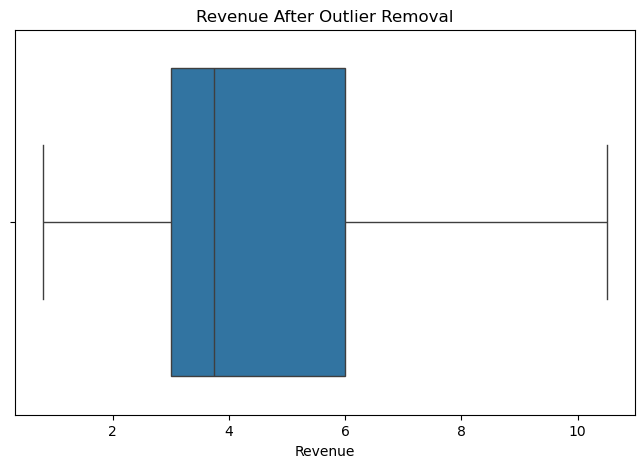

C:\Users\HP\AppData\Local\Temp\ipykernel_15044\726034672.py:123: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(



SUMMARY STATISTICS
       transaction_id               transaction_date  transaction_qty  \
count   145843.000000                         145843    145843.000000   
mean     74684.588043  2023-04-15 10:24:42.278888704         1.438650   
min          1.000000            2023-01-01 00:00:00         1.000000   
25%      37254.500000            2023-03-06 00:00:00         1.000000   
50%      74751.000000            2023-04-24 00:00:00         1.000000   
75%     112080.500000            2023-05-30 00:00:00         2.000000   
max     149456.000000            2023-06-30 00:00:00         4.000000   
std      43149.842349                            NaN         0.532239   

            store_id     product_id     unit_price        Revenue  \
count  145843.000000  145843.000000  145843.000000  145843.000000   
mean        5.343280      48.276839       3.083470       4.356564   
min         3.000000      10.000000       0.800000       0.800000   
25%         3.000000      34.000000       2.50

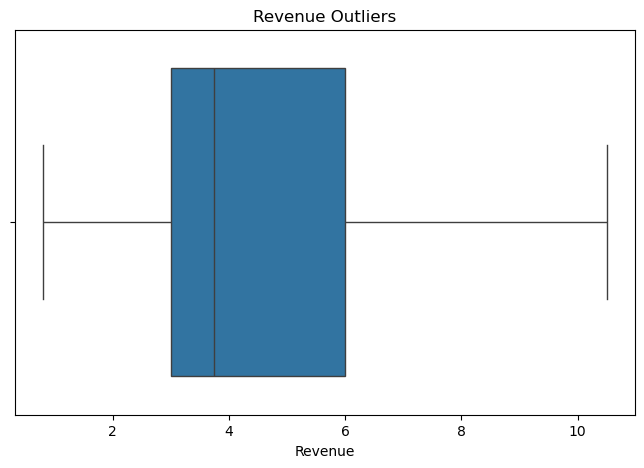

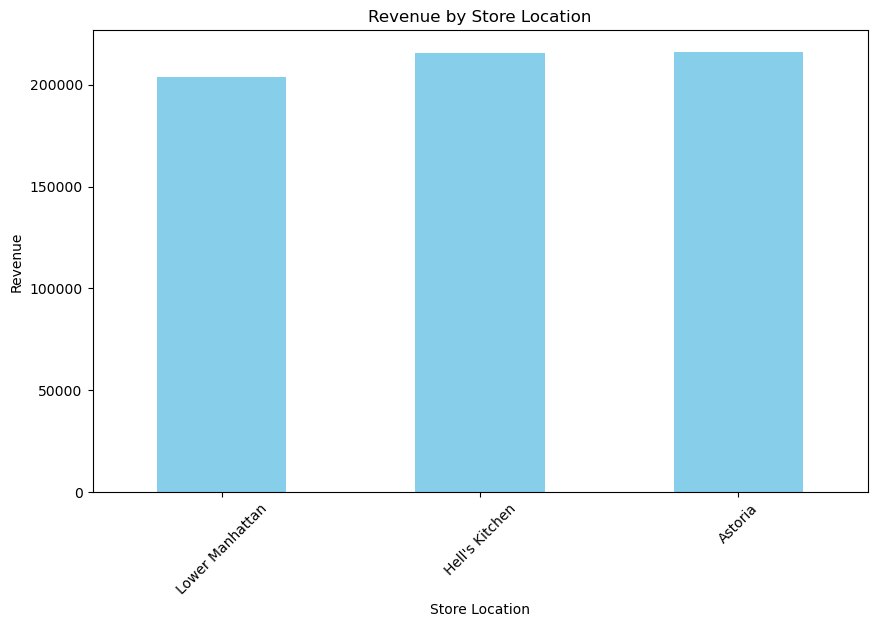

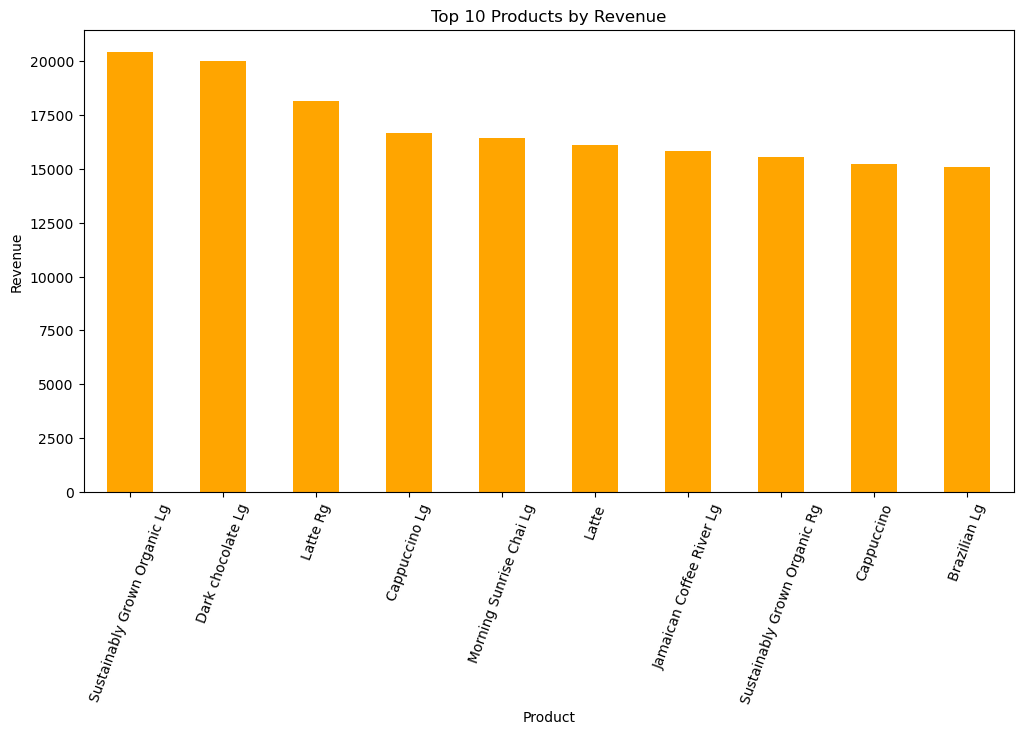

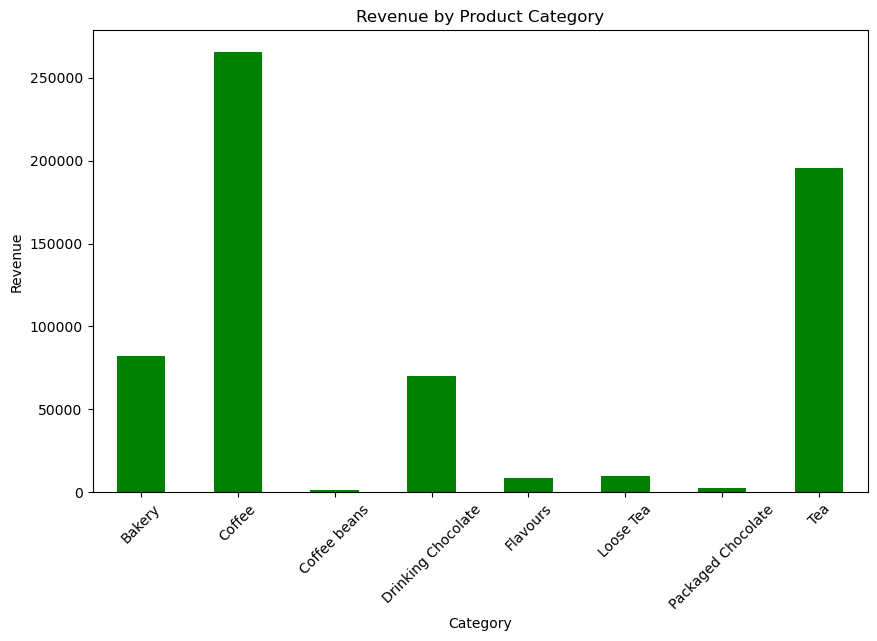

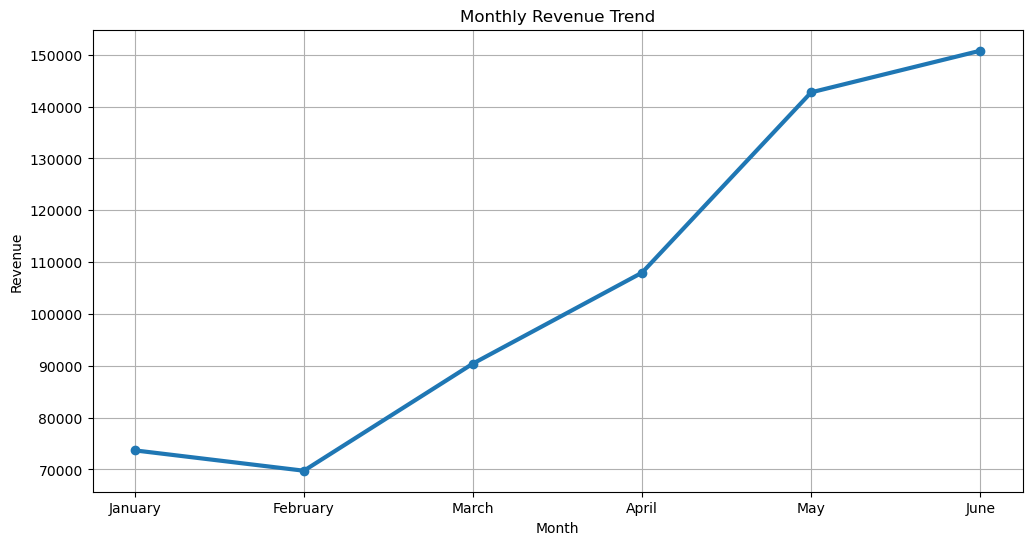

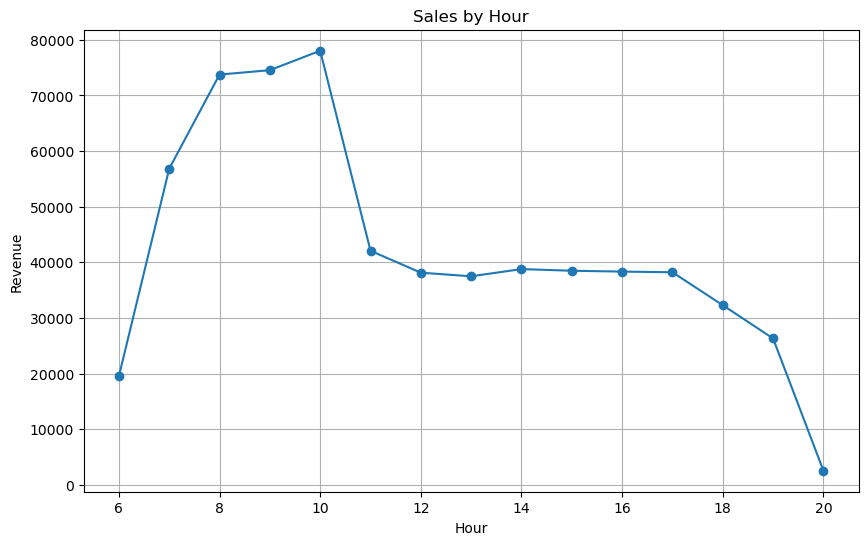

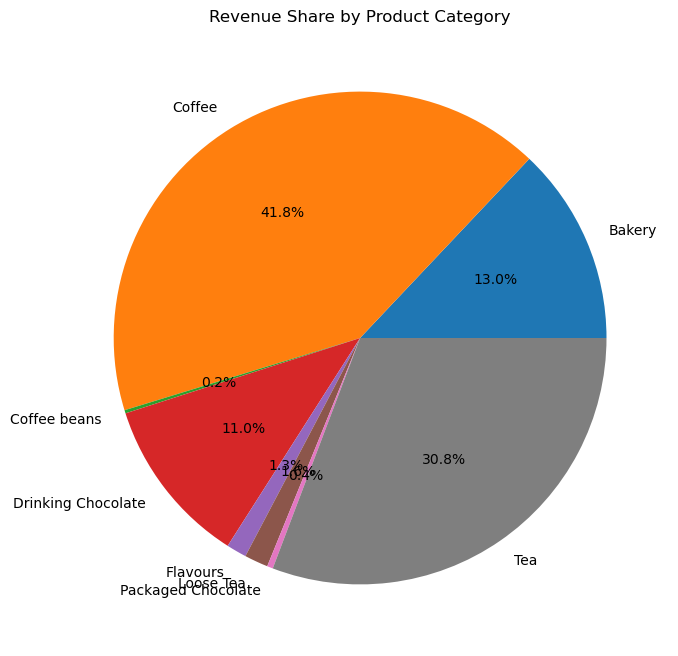

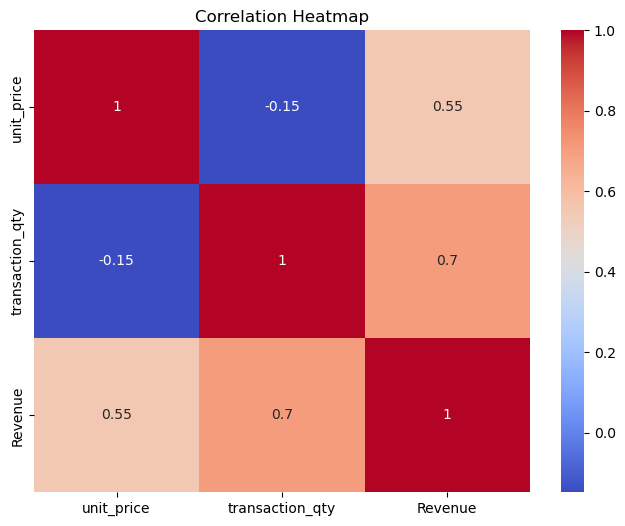

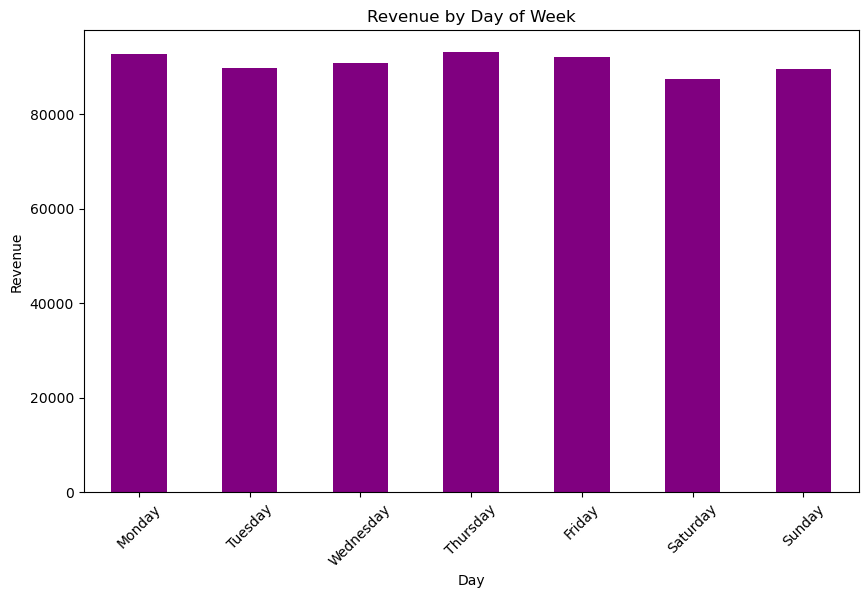


BUSINESS INSIGHTS

Top Store Location:
Astoria

Top Product Category:
Coffee

Top Product:
Sustainably Grown Organic Lg

Best Sales Hour:
10

Total Revenue:
635374.34

Top 5 Products:
product_detail
Sustainably Grown Organic Lg    20439.25
Dark chocolate Lg               20007.00
Latte Rg                        18143.25
Cappuccino Lg                   16664.25
Morning Sunrise Chai Lg         16460.00
Name: Revenue, dtype: float64

Top 5 Store Locations:
store_location
Astoria            215936.05
Hell's Kitchen     215487.65
Lower Manhattan    203950.64
Name: Revenue, dtype: float64
Cleaned dataset saved successfully!


In [16]:
# ==========================================
# COFFEE SHOP SALES ANALYSIS PROJECT
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_excel(
    r"C:\Users\HP\OneDrive\Desktop\Coffee Shop Sales.xlsx"
)

print("================================")
print("DATASET LOADED SUCCESSFULLY")
print("================================")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

# ==========================================
# DATA INFORMATION
# ==========================================

print("\n================================")
print("DATASET INFORMATION")
print("================================")

print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# ==========================================
# HANDLE MISSING VALUES
# ==========================================

df.dropna(inplace=True)

print("\nMissing Values Removed")

# ==========================================
# REMOVE DUPLICATES
# ==========================================

duplicates = df.duplicated().sum()

print("\nDuplicate Rows:", duplicates)

df.drop_duplicates(inplace=True)

# ==========================================
# DATE & TIME CONVERSION
# ==========================================

df['transaction_date'] = pd.to_datetime(
    df['transaction_date'],
    errors='coerce'
)

# Revenue Column

df['Revenue'] = (
    df['unit_price']
    * df['transaction_qty']
)
# ==========================================
# OUTLIER HANDLING USING IQR METHOD
# ==========================================

Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

before_rows = len(df)

df = df[
    (df['Revenue'] >= lower_bound) &
    (df['Revenue'] <= upper_bound)
]

after_rows = len(df)

print("\nRows Before Outlier Removal:", before_rows)
print("Rows After Outlier Removal:", after_rows)
print("Outliers Removed:", before_rows - after_rows)

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Revenue'])
plt.title("Revenue After Outlier Removal")
plt.show()
# Month

df['Month'] = (
    df['transaction_date']
    .dt.month_name()
)

# Day

df['Day'] = (
    df['transaction_date']
    .dt.day_name()
)

# Hour

df['Hour'] = pd.to_datetime(
    df['transaction_time'].astype(str),
    errors='coerce'
).dt.hour

# ==========================================
# SUMMARY STATISTICS
# ==========================================

print("\n================================")
print("SUMMARY STATISTICS")
print("================================")

print(df.describe())

print("\nTotal Revenue:")
print(round(df['Revenue'].sum(), 2))

# ==========================================
# OUTLIER DETECTION
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Revenue']
)

plt.title("Revenue Outliers")
plt.show()

# ==========================================
# REVENUE BY STORE LOCATION
# ==========================================

plt.figure(figsize=(10,6))

store_sales = (
    df.groupby('store_location')['Revenue']
    .sum()
    .sort_values()
)

store_sales.plot(
    kind='bar',
    color='skyblue'
)

plt.title("Revenue by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

# ==========================================
# TOP 10 PRODUCTS BY REVENUE
# ==========================================

plt.figure(figsize=(12,6))

top_products = (
    df.groupby('product_detail')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(
    kind='bar',
    color='orange'
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=70)

plt.show()

# ==========================================
# PRODUCT CATEGORY SALES
# ==========================================

plt.figure(figsize=(10,6))

category_sales = (
    df.groupby('product_category')['Revenue']
    .sum()
)

category_sales.plot(
    kind='bar',
    color='green'
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

# ==========================================
# MONTHLY REVENUE TREND
# ==========================================

month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

monthly_sales = (
    df.groupby('Month')['Revenue']
    .sum()
    .reindex(month_order)
)

plt.figure(figsize=(12,6))

monthly_sales.plot(
    marker='o',
    linewidth=3
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

# ==========================================
# SALES BY HOUR
# ==========================================

plt.figure(figsize=(10,6))

hourly_sales = (
    df.groupby('Hour')['Revenue']
    .sum()
)

hourly_sales.plot(
    kind='line',
    marker='o'
)

plt.title("Sales by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

# ==========================================
# REVENUE SHARE PIE CHART
# ==========================================

plt.figure(figsize=(8,8))

df.groupby(
    'product_category'
)['Revenue'].sum().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.title(
    "Revenue Share by Product Category"
)

plt.show()

# ==========================================
# CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(8,6))

corr = df[
    [
        'unit_price',
        'transaction_qty',
        'Revenue'
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# ==========================================
# SALES BY DAY OF WEEK
# ==========================================

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_sales = (
    df.groupby('Day')['Revenue']
    .sum()
    .reindex(day_order)
)

plt.figure(figsize=(10,6))

day_sales.plot(
    kind='bar',
    color='purple'
)

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

# ==========================================
# BUSINESS INSIGHTS
# ==========================================

print("\n================================")
print("BUSINESS INSIGHTS")
print("================================")

print(
    "\nTop Store Location:"
)

print(
    df.groupby('store_location')['Revenue']
    .sum()
    .idxmax()
)

print(
    "\nTop Product Category:"
)

print(
    df.groupby('product_category')['Revenue']
    .sum()
    .idxmax()
)

print(
    "\nTop Product:"
)

print(
    df.groupby('product_detail')['Revenue']
    .sum()
    .idxmax()
)

print(
    "\nBest Sales Hour:"
)

print(
    df.groupby('Hour')['Revenue']
    .sum()
    .idxmax()
)

print(
    "\nTotal Revenue:"
)

print(
    round(
        df['Revenue'].sum(),
        2
    )
)

print("\nTop 5 Products:")

print(
    df.groupby('product_detail')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("\nTop 5 Store Locations:")

print(
    df.groupby('store_location')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)
df.to_csv("cleaned_coffee_shop_sales.csv", index=False)

print("Cleaned dataset saved successfully!")


In [18]:
import os

print(os.path.exists(r"C:\Users\HP\OneDrive\Desktop\cleaned_coffee_shop_sales.csv"))

False


In [20]:
df.to_csv("cleaned_coffee_shop_sales.csv", index=False)

print("File saved successfully!")

File saved successfully!


In [22]:
import os

print("Current Folder:")
print(os.getcwd())

Current Folder:
C:\Users\HP


In [24]:
df.to_csv(
    r"C:\Users\HP\OneDrive\Desktop\cleaned_coffee_shop_sales.csv",
    index=False
)

print("Saved to Desktop Successfully!")

Saved to Desktop Successfully!
